In [92]:
# BPDRR
# extract information of distance matrix for each Damage Scenario 1 to 5
# Mario Castro-Gama
# 2026-05-20

In [93]:
import wntr
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
#from colorspacious import cspace_converter
from collections import OrderedDict

In [94]:
import networkx as nx

In [95]:
import seaborn as sns

In [96]:
# this is to remove warnings from showing as pink blocks as results of CELLS
import warnings
warnings.filterwarnings("ignore")

In [97]:
# load the wdn as INP file
wn = wntr.network.WaterNetworkModel('BBM-EPS.inp') 

In [98]:
wn.describe(3)

{'Nodes': {'Junctions': 4909, 'Tanks': 5, 'Reservoirs': 1},
 'Links': {'Pipes': 6064,
  'Pumps': {'Head': 4, 'Power': 0},
  'Valves': {'PRV': 0, 'PSV': 0, 'PBV': 0, 'TCV': 6, 'FCV': 0, 'GPV': 0}},
 'Patterns': 3,
 'Curves': {'Pump': 4, 'Efficiency': 0, 'Headloss': 0, 'Volume': 0},
 'Sources': 0,
 'Controls': 0}

In [99]:
# function to check if matrix is symmetric
def check_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)

In [100]:
# function to create length of valves and pumps as 5.0 meters
def sim_length(i,pipes,wn):
    if i in pipes:
        return wn.get_link(i).length
    else:
        return 5.0

In [101]:
# load the information required 
file_rep = 'BPDRR_reparations.xlsx'
ds_sel = 'DS5' # which damage scenario to analyse
file_distance = 'BBM_distances_'+ds_sel+'.csv'
FlagSave = 1
FlagPlot = 1

pipes_interest = pd.read_excel(file_rep, 
                               sheet_name=ds_sel,
                               #header=True, 
                               #index_col=0,
                              )
print(pipes_interest)

    Junction  Coefficient  Pipe ID
0      E3922      2.42800     3922
1      E3398      2.42800     3398
2      E3825      2.42800     3825
3      E4117      2.42800     4117
4      E1902      1.36575     1902
..       ...          ...      ...
103     E587      0.29025      587
104    E5893      0.29025     5893
105     E772      0.29025      772
106      E90      0.29025       90
107      E98      0.29025       98

[108 rows x 3 columns]


In [102]:
# Get the networkx graph (undirected)
G = wn.to_graph(link_weight='length').to_undirected()

# Get all relevant nodes: junctions, tanks, reservoirs
junctions  = wn.junction_name_list 
tanks      = wn.tank_name_list
reservoirs = wn.reservoir_name_list

nodes = junctions + tanks + reservoirs  # All node types
len(nodes)

4915

In [103]:
# Now get a different Graph where distances will be estimated
pipes  = wn.pipe_name_list
valves = wn.valve_name_list 
pumps  = wn.pump_name_list
links  = pipes + valves + pumps

start_node = [wn.get_link(i).start_node.name for i in pipes_interest['Pipe ID']]
final_node = [wn.get_link(i).end_node.name for i in pipes_interest['Pipe ID']]

l_dir = {(wn.get_link(i).start_node.name, 
          wn.get_link(i).end_node.name,
          sim_length(i,pipes,wn)) for i in links}

H = nx.Graph()
H.add_weighted_edges_from(l_dir)
H.number_of_nodes(), H.number_of_edges()

(4915, 6061)

In [105]:
# if loaded correctly then these values correspond to the number of reparations of the damage scenario on the excel file
len(start_node), len(final_node)

(108, 108)

In [106]:
# Initialize distance matrix
DD = pd.DataFrame(index=start_node, columns=final_node, dtype=float)

In [107]:
# Compute shortest path lengths using Dijkstra (based on pipe lengths)
for i in start_node:
    lengths = nx.single_source_dijkstra_path_length(H, i, weight='weight')
    for j in final_node:
        DD.loc[i, j] = round(lengths.get(j, np.inf),2)  # np.inf if no path exists

print('D filtered is symmetric : '+str(check_symmetric(DD)))

D filtered is symmetric :False


In [108]:
# show me the matrix of distances DD where 
# rows : are inital node of the pipe 
# cols : are final node of the pipe 
DD

,33261,32744,33136,33272,21565,32541,10075,11289,21697,21776,...,54256,54393,54449,54806,54715,10491,54771,10635,10142,10081
33116,188.34,1295.71,1138.32,620.75,4454.47,1645.62,4413.55,4491.92,3885.91,4126.05,...,11599.00,11541.88,11292.97,10688.95,11109.42,4225.94,10739.97,3940.76,4827.76,4000.06
32727,1464.95,123.27,545.41,1857.82,3264.29,369.01,3223.37,3908.75,2695.73,2935.87,...,10408.82,10351.70,10102.79,9498.77,9919.24,3642.77,9549.79,3357.59,3637.58,2809.88
33044,1220.54,316.02,106.12,1593.42,3547.28,808.30,3506.36,3469.46,2978.72,3218.86,...,10691.81,10634.69,10385.78,9781.76,10202.23,3203.48,9832.78,2918.30,3920.57,3092.87
33265,919.11,1986.94,1809.56,110.02,5145.70,2336.85,5104.78,5163.16,4577.14,4817.28,...,12290.23,12233.11,11984.20,11380.18,11800.65,4897.18,11431.20,4612.00,5518.99,4691.29
21659,4514.49,3259.24,3525.08,4907.36,191.04,3504.98,2963.21,5335.97,2241.59,2855.13,...,11161.50,11104.38,10855.47,10251.45,10671.92,4640.58,10302.47,4675.37,3377.42,2990.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10516,4381.47,3486.69,3064.55,4754.35,4798.81,3978.97,2915.48,2505.31,5396.42,5636.56,...,10306.25,10249.13,10000.22,9396.20,9816.67,32.81,9447.22,1220.31,3329.69,2501.99
54763,10835.03,9579.78,9845.62,11227.90,10400.23,9825.52,8433.64,10082.14,10709.26,10949.40,...,1613.26,1714.33,963.87,1505.28,462.73,9386.75,93.28,9421.54,8847.85,8020.15
10643,4066.63,3171.85,2749.71,4439.51,4803.94,3664.13,2920.61,1769.72,5401.55,5641.69,...,10311.38,10254.26,10005.35,9401.33,9821.80,1190.65,9452.35,62.47,3334.82,2507.12
10074,4841.47,3586.22,3852.06,5234.34,3393.83,3831.96,239.58,3883.26,4715.70,4955.84,...,9625.53,9568.41,9319.50,8715.48,9135.95,3187.87,8766.50,3222.66,174.63,1112.41


In [109]:
if FlagSave:
    # Save distance matrix for additional checks as a CSV file
    DD.to_csv(file_distance, 
              sep=',', 
              header=True, index=True)

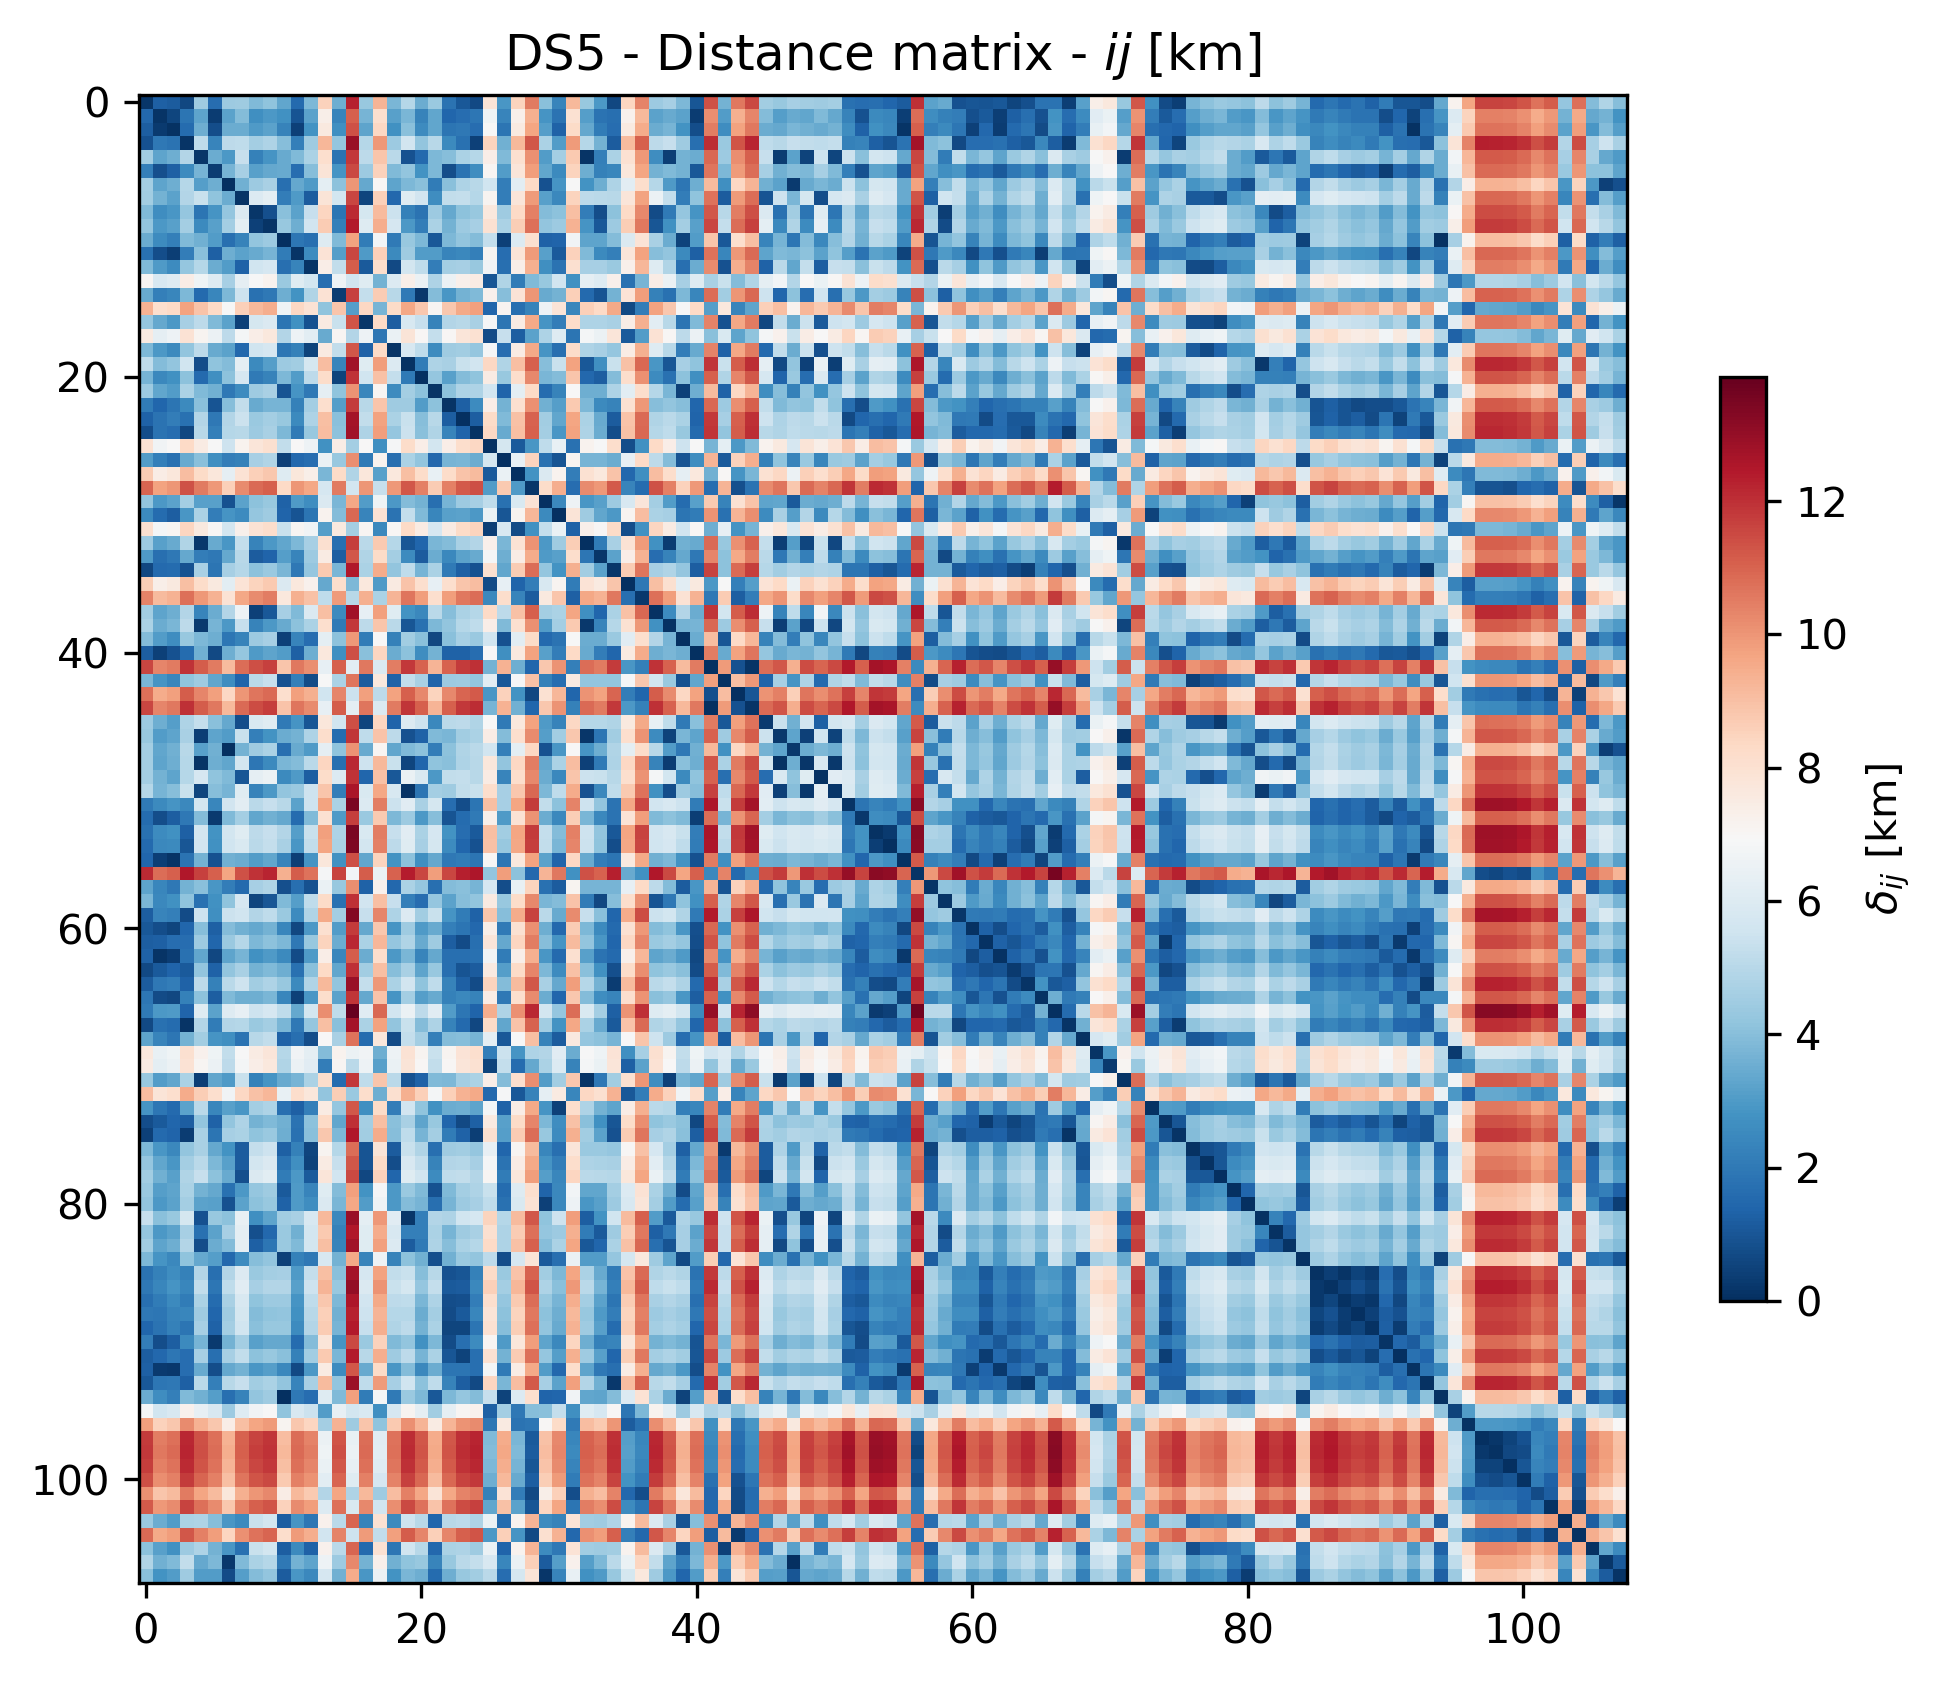

In [110]:
if FlagPlot:
    # DD : Distances (original values). 
    # Diagonal is not zero as it corresponds to each pipe length
    fig1 = plt.figure(figsize=(8,8))
    plt.imshow(DD/1000,cmap='RdBu_r') # divide 1000 m to km
    plt.title(ds_sel+' - Distance matrix - $ij$ [km]')
    plt.colorbar(shrink=0.5,label='$\\delta_{ij}$ [km]') 
    plt.rcParams['figure.figsize'] = (8, 8) 
    plt.rcParams['savefig.dpi'] = 300 
    plt.rcParams['figure.dpi'] = 300
    plt.savefig(r'BPDRR_distances_'+ds_sel+'.jpg' , bbox_inches='tight')

    plt.show()

In [111]:
# estimate the mean value of the distances per COLUMNS and order ascending
mean_cols = DD.mean(axis=0).sort_values(ascending=True)
new_cols = mean_cols.keys()
new_cols

Index(['32744', '32845', '33054', '32965', '33136', '10328', '32756', '10327',
       '33315', '10216',
       ...
       '54715', '54449', '54867', '54393', '54877', '54256', '54196', '43906',
       '54582', '44107'],
      dtype='object', length=108)

In [112]:
# estimate the mean value of the distances per ROWS and order ascending
mean_rows = DD.mean(axis=1).sort_values(ascending=True)
new_rows = mean_rows.keys()
new_rows

Index(['32826', '32727', '32963', '33044', '10317', '10236', '33055', '10328',
       '32736', '10400',
       ...
       '54763', '54396', '54737', '54510', '54869', '54863', '54377', '54194',
       '54295', '54598'],
      dtype='object', length=108)

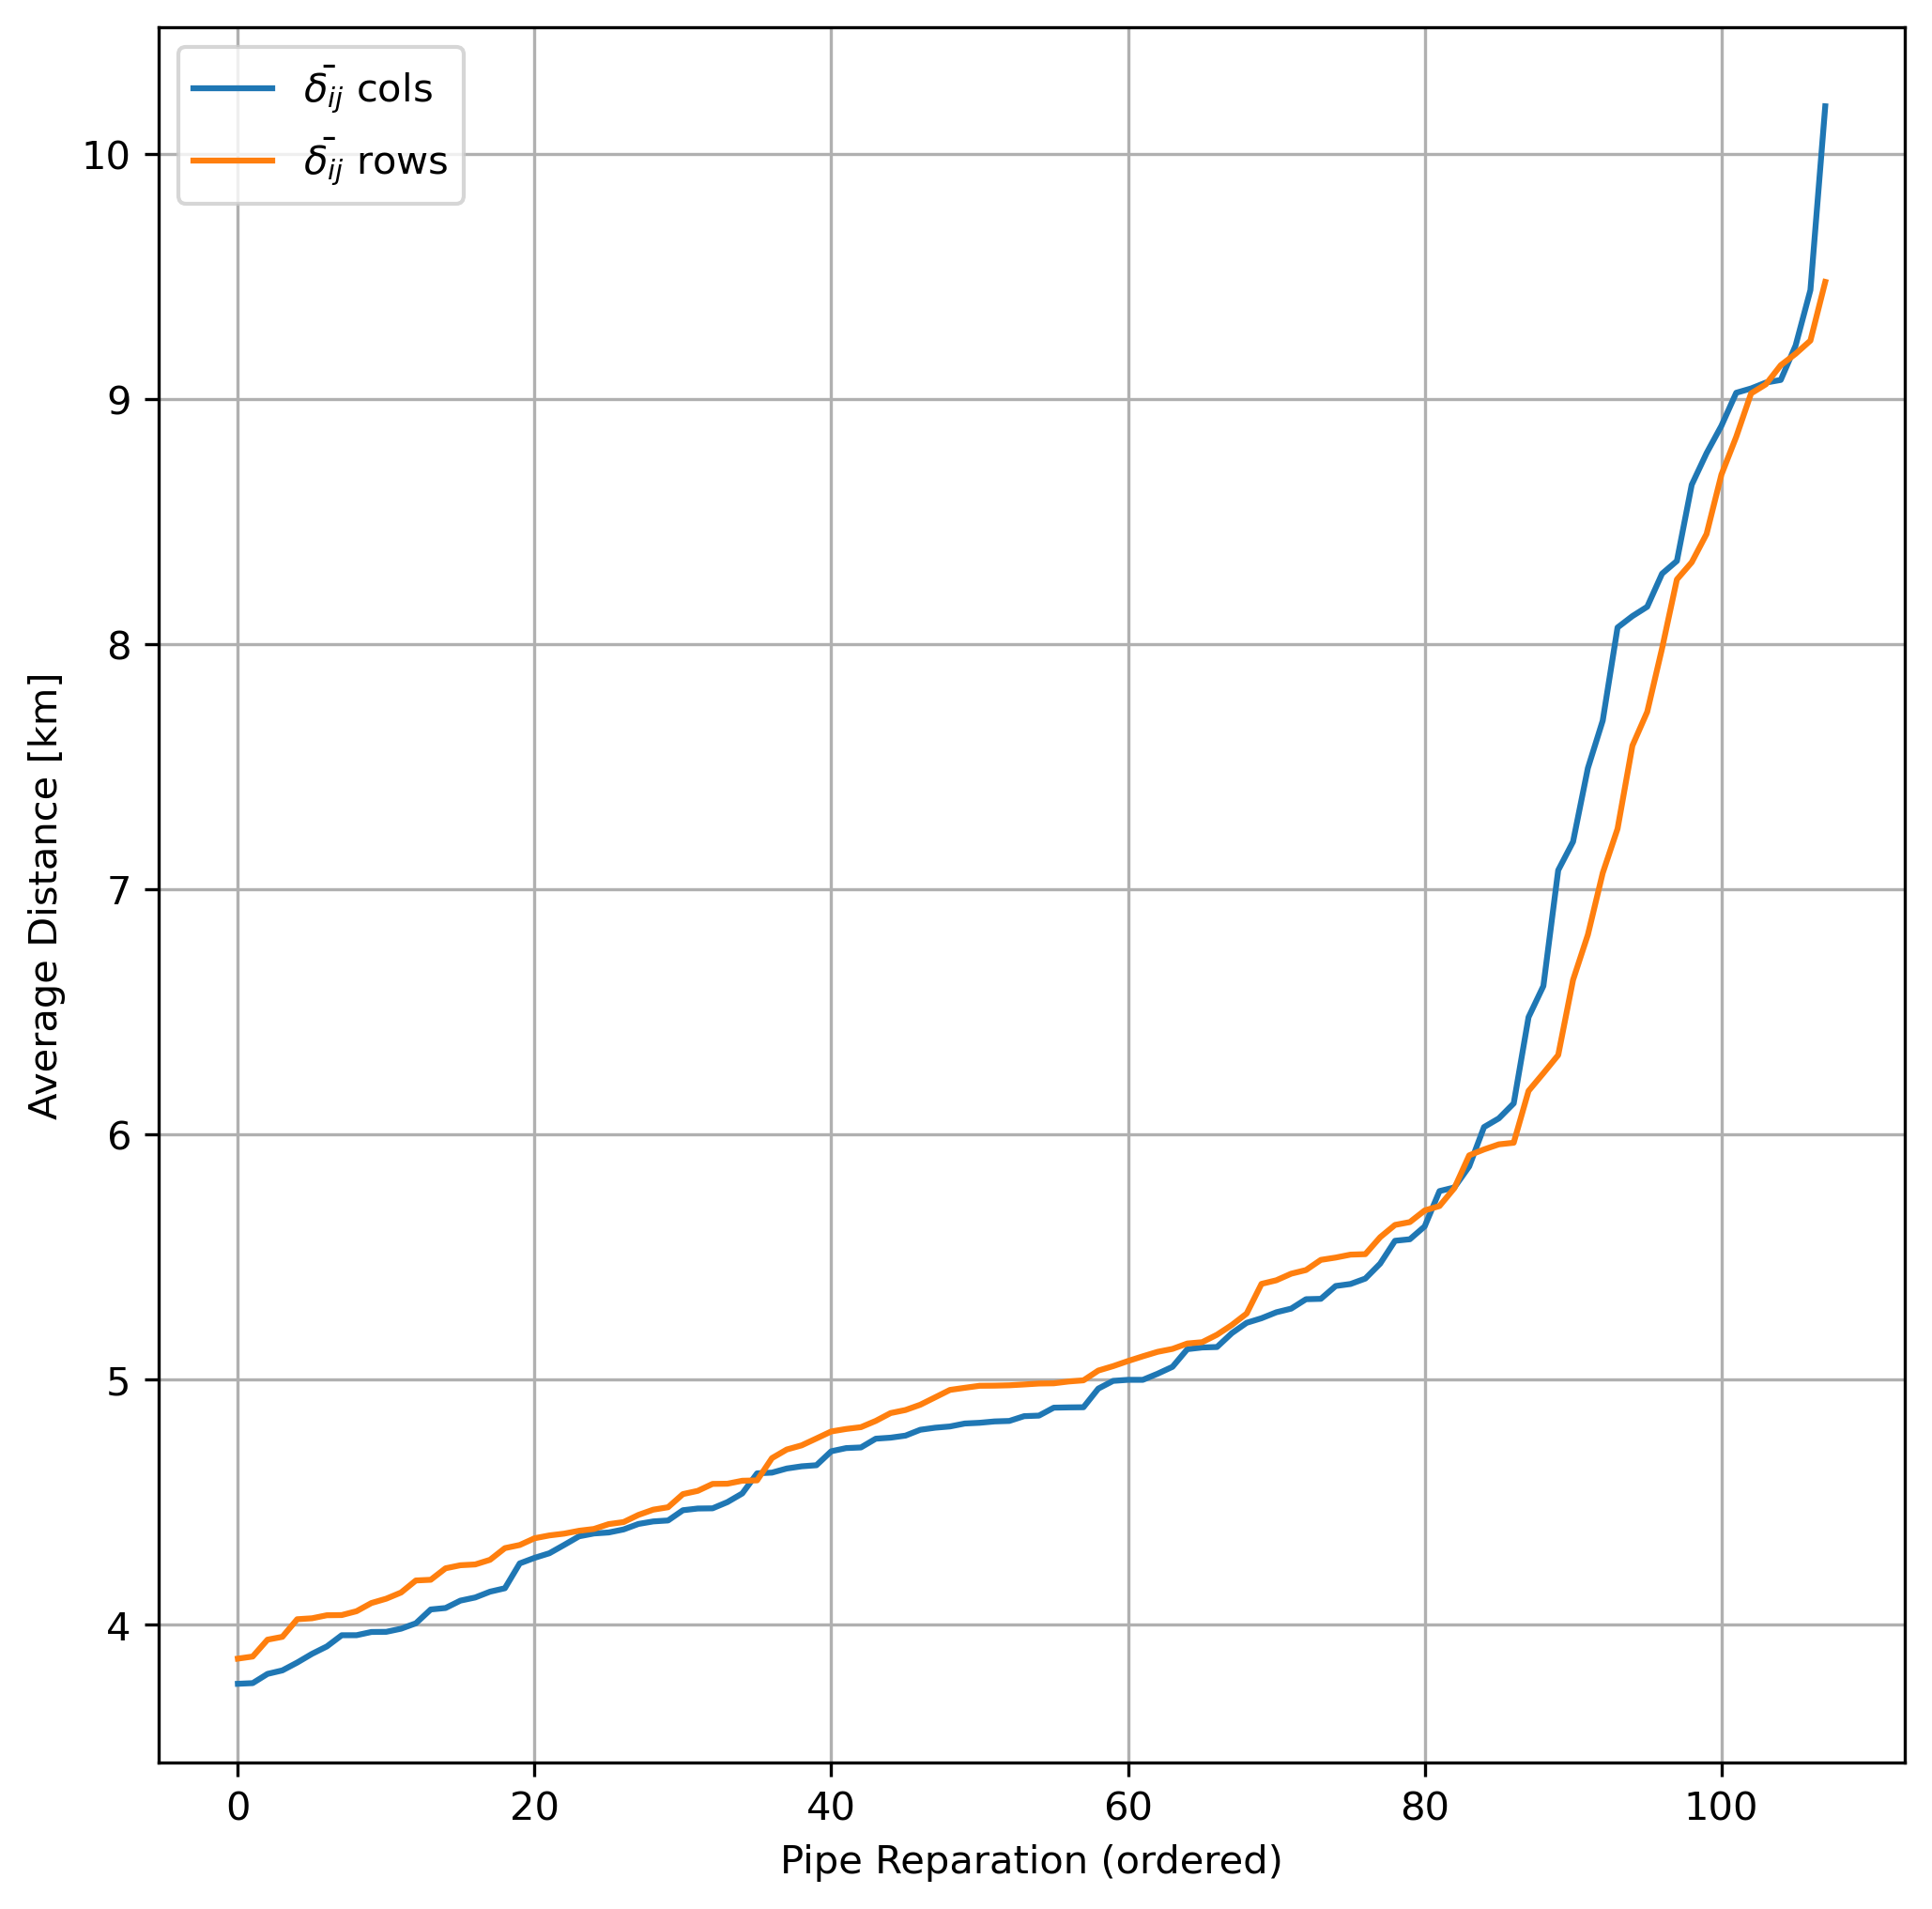

In [113]:
figD = plt.figure(figsize=(8,8))
plt.plot(mean_cols.values/1000,label='$\\bar{\\delta_{ij}}$ cols')
plt.plot(mean_rows.values/1000,label='$\\bar{\\delta_{ij}}$ rows')
#plt.plot(mean_cols.values/1000,mean_rows.values/1000,label='$\\bar{\\delta_{ij}}$ rows')
#plt.plot([4,10],[4,10],'k:')
plt.grid(which='both')
plt.legend()
plt.ylabel('Average Distance [km]')
plt.xlabel('Pipe Reparation (ordered)')
plt.show()

In [114]:
# Create new distance matrix reordered by average distance first cols then rows
DD2 = DD[new_cols]
DD2 = DD2.loc[new_rows]

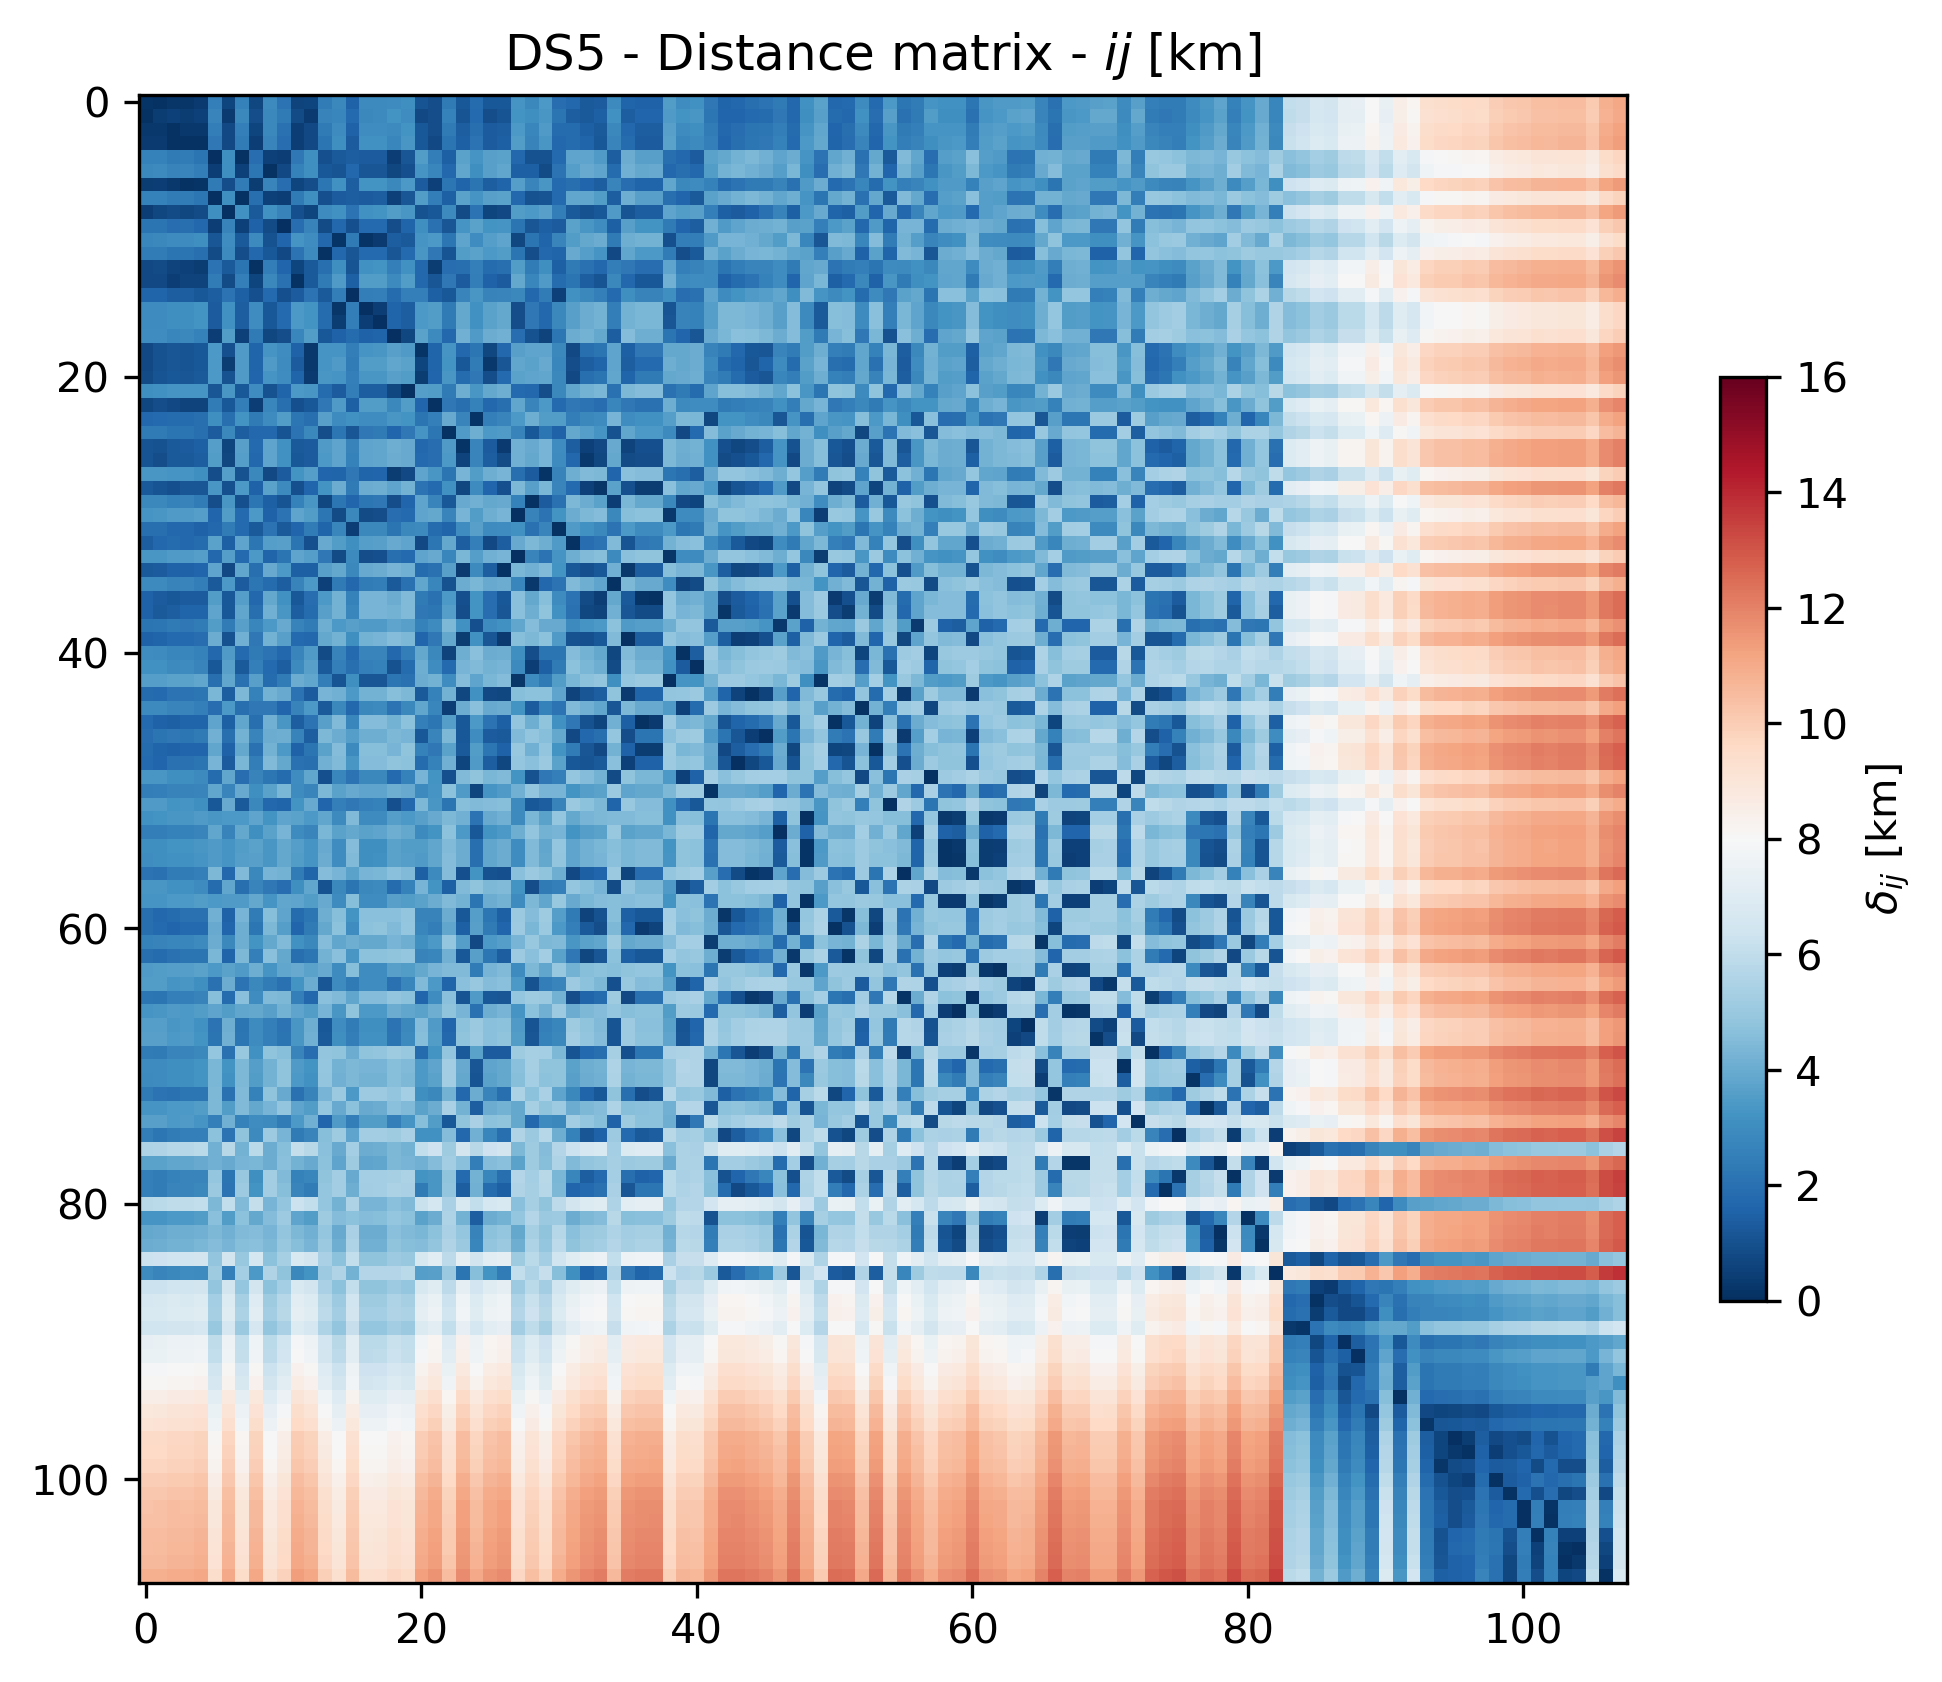

In [116]:
# draw imshow of distances reordered by average distance on rows and columns.
# DD2 is divided by 1000 to convert from m to km
fig1 = plt.figure(figsize=(8,8))
plt.imshow(DD2/1000, # divide 1000 m to km
           cmap='RdBu_r',
           vmin=0,
           vmax=16,
          ) 
plt.title(ds_sel+' - Distance matrix - $ij$ [km]')
plt.colorbar(shrink=0.5,label='$\\delta_{ij}$ [km]') 

plt.rcParams['figure.figsize'] = (6, 6) 
plt.rcParams['savefig.dpi'] = 300 
plt.rcParams['figure.dpi'] = 300
plt.savefig(r'BPDRR_ordered_distances_'+ds_sel+'.jpg' , bbox_inches='tight')

plt.show()

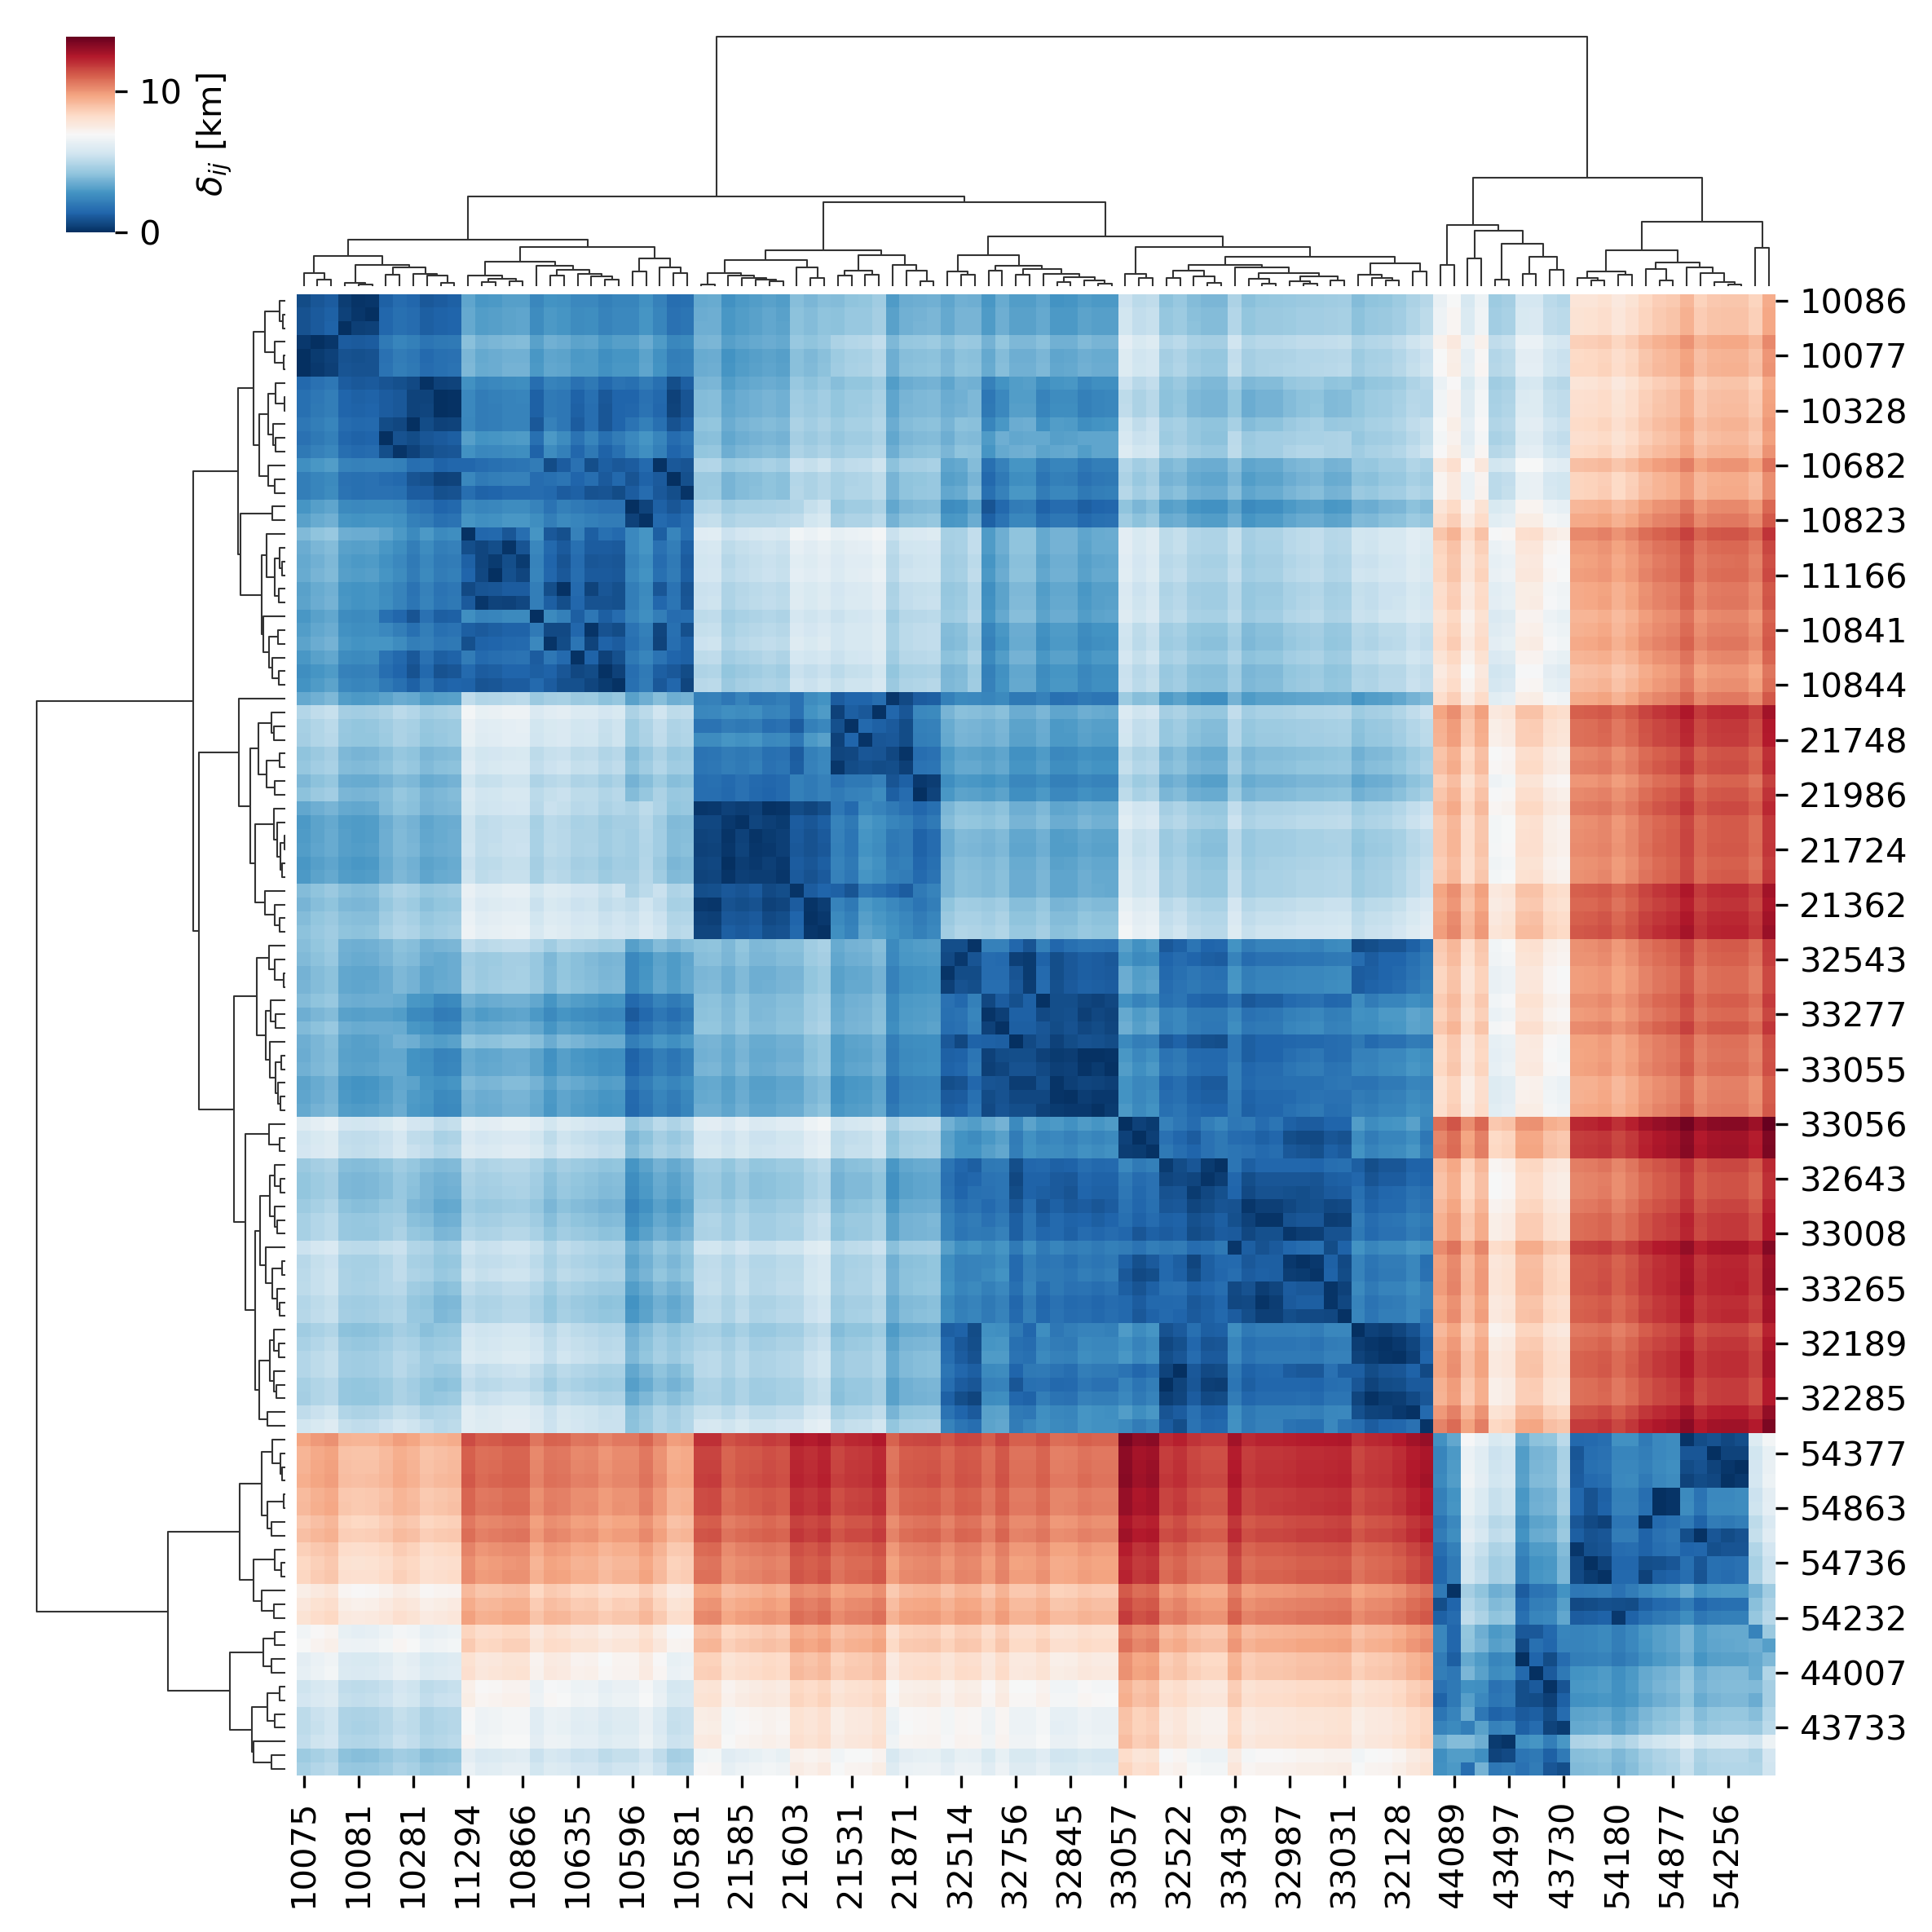

In [117]:
# create a dendrogram of the matrix DD2
# This can indicate geographical clustering
g = sns.clustermap(DD2/1000, # m to km
                   cmap="RdBu_r",
                   method="average",
                   cbar_pos=(0.04, 0.875, 0.025, 0.10),
                   cbar_kws={'label':'$\\delta_{ij}$ [km]'},
                   dendrogram_ratio = 0.15,
                   figsize=(8,8),
                  )
g.savefig('BPDRR_dendrogram_'+ds_sel+'.png') 
order = g.dendrogram_row.reordered_ind
DD_order = DD.iloc[order, order]